# Kaggle Data - **Bank_Customer_Churn_Prediction**

## About Dataset
- **RowNumber**—corresponds to the record (row) number and has no effect on the output. 
- **CustomerId**—contains random values and has no effect on customer leaving the bank. 
- **Surname**—the surname of a customer has no impact on their decision to leave the bank. 
- **CreditScore**—can have an effect on customer churn, since a customer with a higher credit score is less likely to leave the bank. 
- **Geography**—a customer’s location can affect their decision to leave the bank. 
- **Gender**—it’s interesting to explore whether gender plays a role in a customer leaving the bank. 
- **Age**—this is certainly relevant, since older customers are less likely to leave their bank than younger ones. 
- **Tenure**—refers to the number of years that the customer has been a client of the bank. Normally, older clients are more loyal and less likely to         leave a bank. 
- **Balance**—also a very good indicator of customer churn, as people with a higher balance in their accounts are less likely to leave the bank compared      to those with lower balances. 
- **NumOfProducts**—refers to the number of products that a customer has purchased through the bank. 
- **HasCrCard**—denotes whether or not a customer has a credit card. This column is also relevant, since people with a credit card are less likely to         leave the bank. 
- **IsActiveMember**—active customers are less likely to leave the bank. 
- **EstimatedSalary**—as with balance, people with lower salaries are more likely to leave the bank compared to those with higher salaries. 
- **Exited**—whether or not the customer left the bank. 
- **Complain**—customer has complaint or not. Satisfaction Score—Score provided by the customer for their complaint resolution. 
- **Card Type**—type of card hold by the customer. 
- **Points Earned**—the points earned by the customer for using credit card.

#### Acknowledgements

As we know, it is much more expensive to sign in a new client than keeping an existing one.

It is advantageous for banks to know what leads a client towards the decision to leave the company.

Churn prevention allows companies to develop loyalty programs and retention campaigns to keep as many customers as possible.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the Data

In [2]:
df = pd.read_csv('./Customer-Churn-Records.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

#### Duplicated Value in Each column

In [5]:
for dup in df.columns:
    print(df[dup].duplicated().value_counts())
    print('-'*50,'\n')

RowNumber
False    10000
Name: count, dtype: int64
-------------------------------------------------- 

CustomerId
False    10000
Name: count, dtype: int64
-------------------------------------------------- 

Surname
True     7068
False    2932
Name: count, dtype: int64
-------------------------------------------------- 

CreditScore
True     9540
False     460
Name: count, dtype: int64
-------------------------------------------------- 

Geography
True     9997
False       3
Name: count, dtype: int64
-------------------------------------------------- 

Gender
True     9998
False       2
Name: count, dtype: int64
-------------------------------------------------- 

Age
True     9930
False      70
Name: count, dtype: int64
-------------------------------------------------- 

Tenure
True     9989
False      11
Name: count, dtype: int64
-------------------------------------------------- 

Balance
False    6382
True     3618
Name: count, dtype: int64
---------------------------------------

#### Show the top 10 Total Values for each columns

In [6]:
for col in df.columns:
    print('\n',col,':')
    print(f'Total unique Values : {len(df[col].unique())}')
    print('-'*50)
    print(df[col].value_counts().head(10))
    print('*'*50)


 RowNumber :
Total unique Values : 10000
--------------------------------------------------
RowNumber
9984    1
9983    1
9982    1
9981    1
9980    1
9979    1
9978    1
9977    1
9976    1
9975    1
Name: count, dtype: int64
**************************************************

 CustomerId :
Total unique Values : 10000
--------------------------------------------------
CustomerId
15656710    1
15768163    1
15672754    1
15719276    1
15692664    1
15703563    1
15579969    1
15656062    1
15666295    1
15695474    1
Name: count, dtype: int64
**************************************************

 Surname :
Total unique Values : 2932
--------------------------------------------------
Surname
Smith       32
Scott       29
Martin      29
Walker      28
Brown       26
Genovese    25
Yeh         25
Shih        25
Wright      24
Maclean     24
Name: count, dtype: int64
**************************************************

 CreditScore :
Total unique Values : 460
-------------------------------

In [7]:
df.describe().round()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0,10000.0
mean,5000.0,15690941.0,651.0,39.0,5.0,76486.0,2.0,1.0,1.0,100090.0,0.0,0.0,3.0,607.0
std,2887.0,71936.0,97.0,10.0,3.0,62397.0,1.0,0.0,0.0,57510.0,0.0,0.0,1.0,226.0
min,1.0,15565701.0,350.0,18.0,0.0,0.0,1.0,0.0,0.0,12.0,0.0,0.0,1.0,119.0
25%,2501.0,15628528.0,584.0,32.0,3.0,0.0,1.0,0.0,0.0,51002.0,0.0,0.0,2.0,410.0
50%,5000.0,15690738.0,652.0,37.0,5.0,97199.0,1.0,1.0,1.0,100194.0,0.0,0.0,3.0,605.0
75%,7500.0,15753234.0,718.0,44.0,7.0,127644.0,2.0,1.0,1.0,149388.0,0.0,0.0,4.0,801.0
max,10000.0,15815690.0,850.0,92.0,10.0,250898.0,4.0,1.0,1.0,199992.0,1.0,1.0,5.0,1000.0


### Visualize the data to find the insights

Text(0.5, 1.0, 'Pair PLot of df')

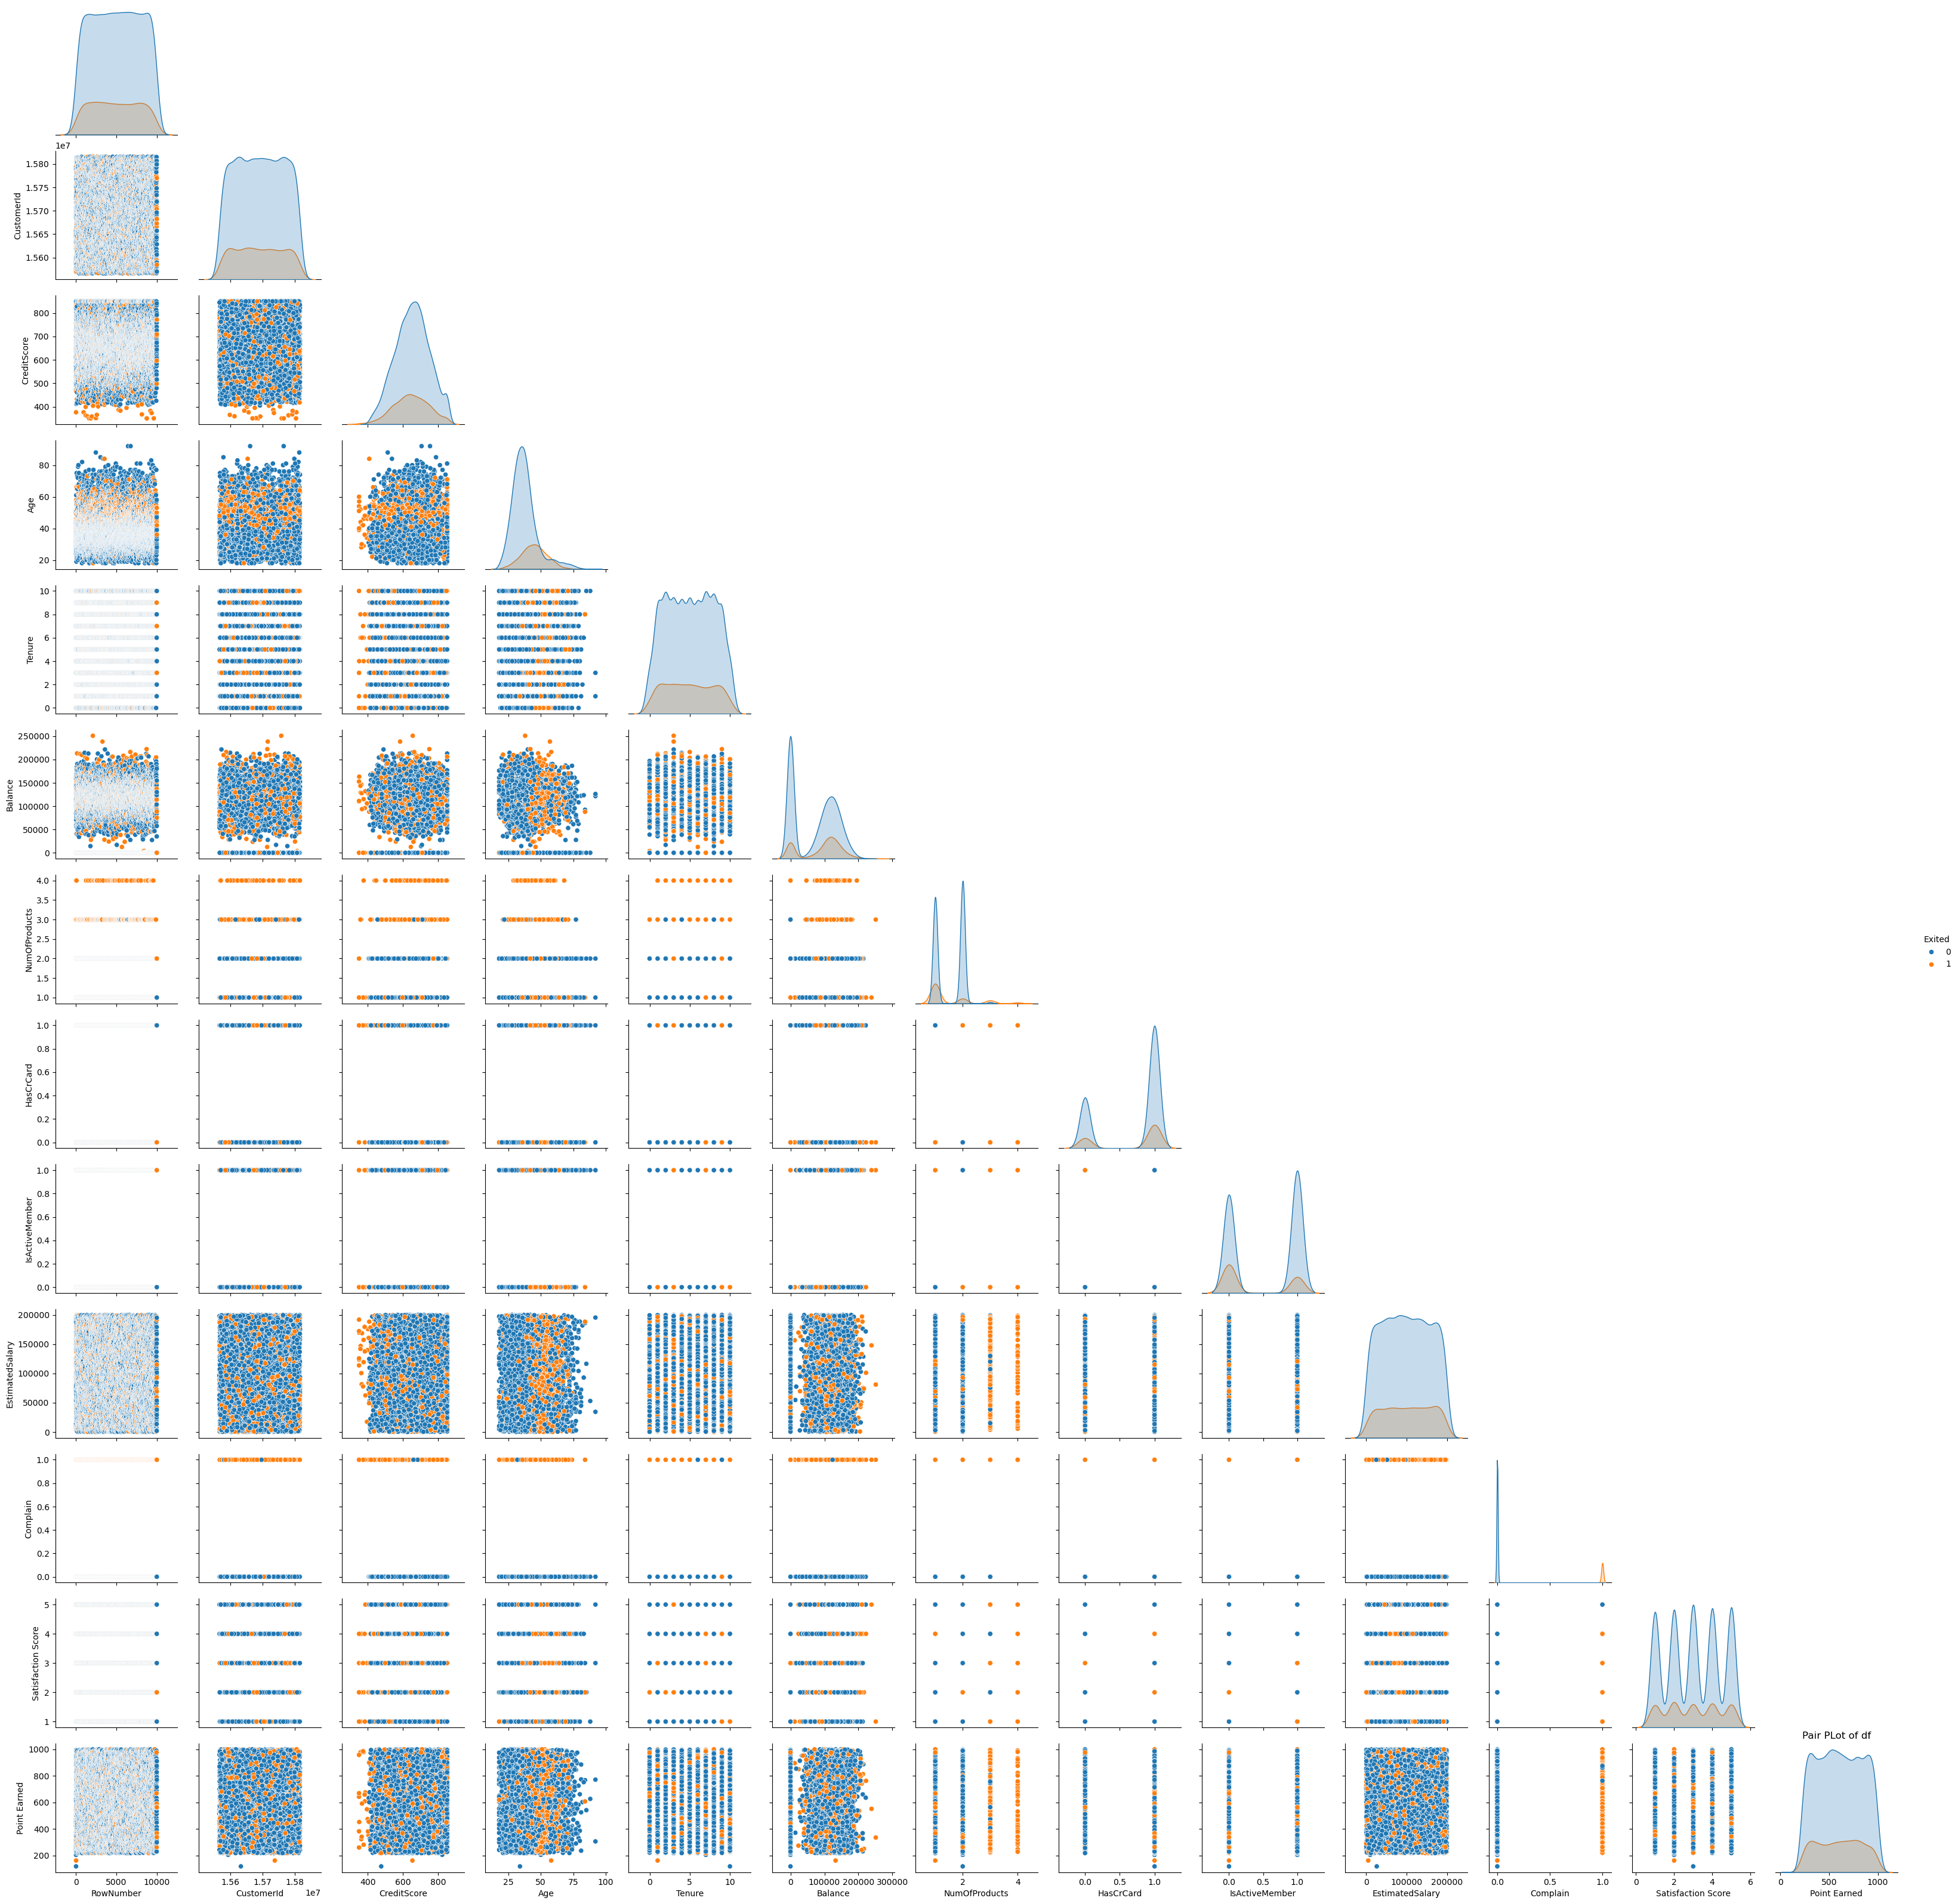

In [8]:
sns.pairplot(df,hue ='Exited',corner=True)
plt.title('Pair PLot of df')

In [9]:
numeric_data = df.select_dtypes(include = np.number)

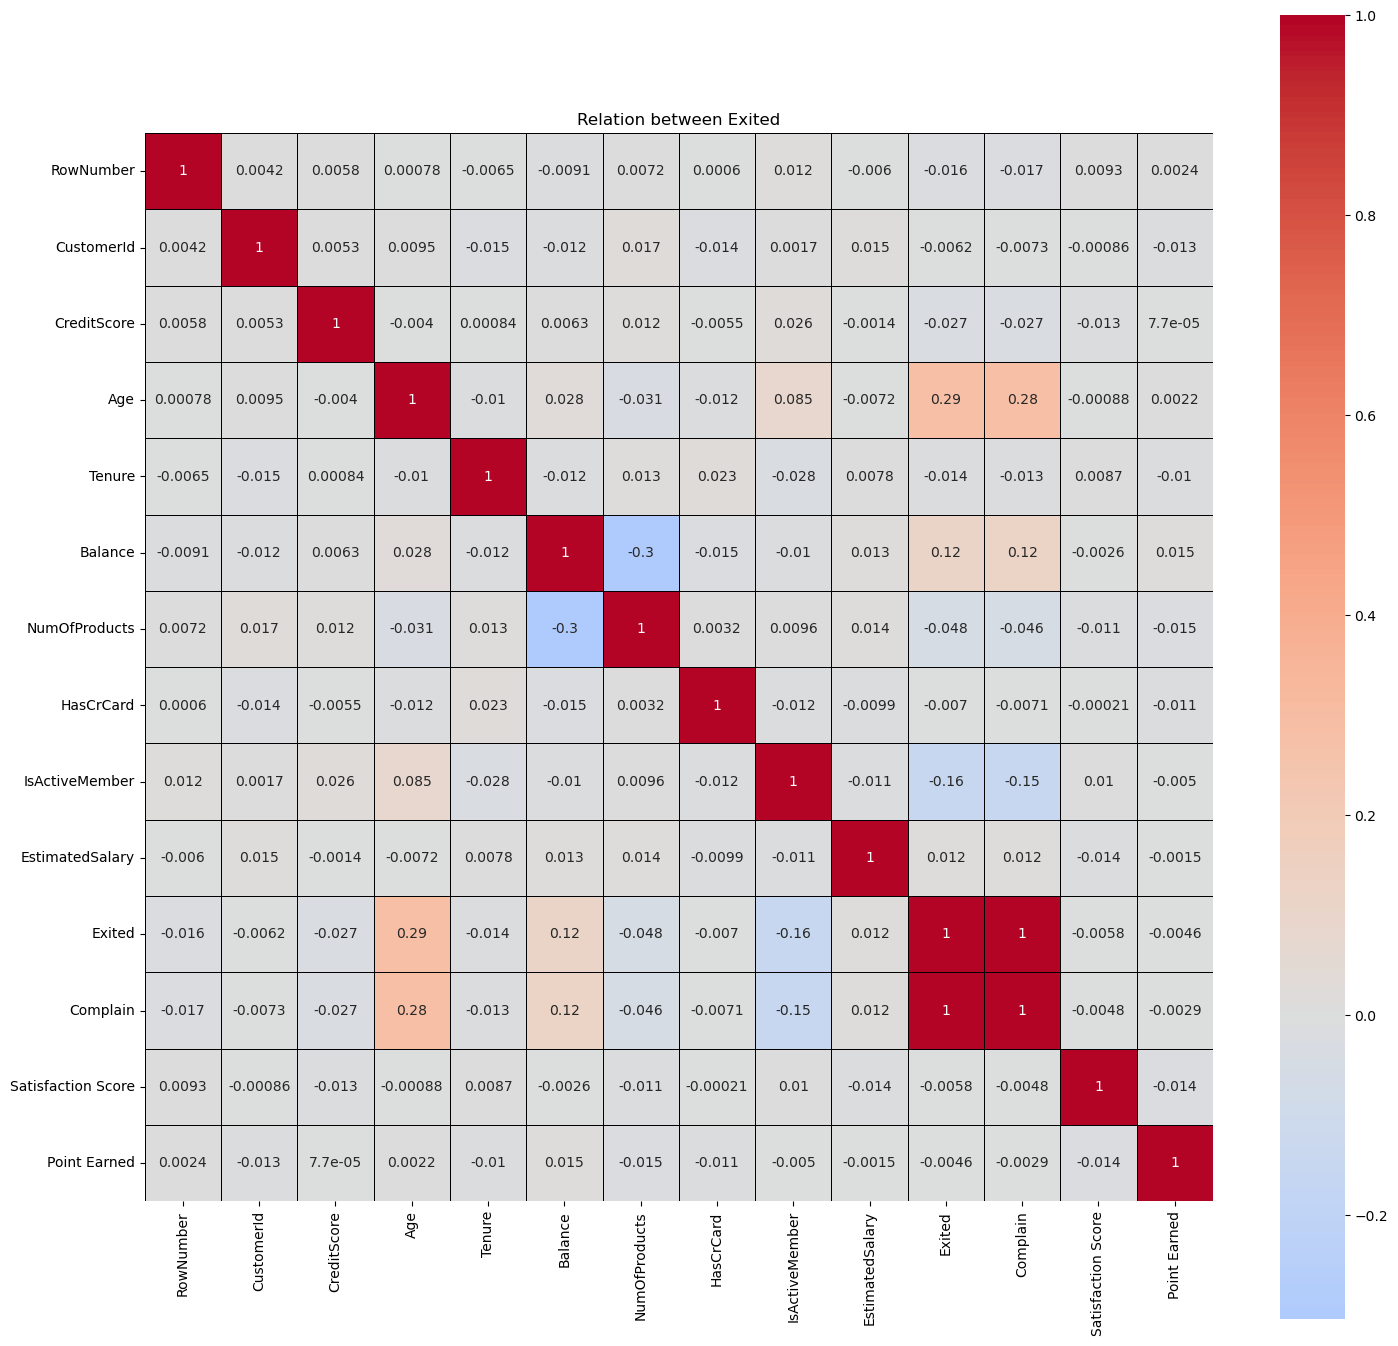

In [10]:
plt.figure(figsize=(15,14))
sns.heatmap(numeric_data.corr(),cmap='coolwarm',annot=True,square=True,center=0,linewidths=0.5,linecolor='black')
plt.title('Relation between Exited')
plt.tight_layout()

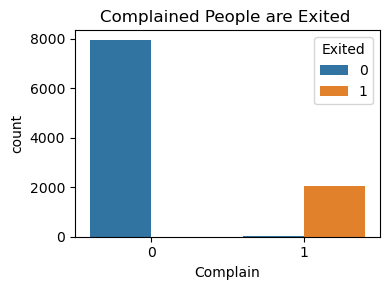

In [11]:
plt.figure(figsize=(4,3))
sns.countplot(data = df,x='Complain',hue='Exited')
plt.title('Complained People are Exited ')
plt.tight_layout()

<Figure size 400x300 with 0 Axes>

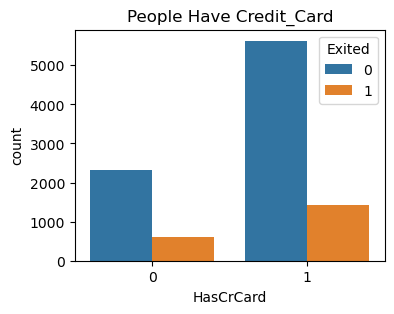

<Figure size 400x300 with 0 Axes>

In [12]:
plt.figure(figsize=(4,3))
sns.countplot(data = df,x='HasCrCard',hue='Exited')
plt.title('People Have Credit_Card')
plt.figure(figsize=(4,3))

In [13]:
df = df.drop(['RowNumber','CustomerId','Surname','Complain'],axis =1) # drop the near 0 relation column and also drop the Complain column this was the higly corelated column that cause the leakage of predictionn

In [14]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0,1,DIAMOND,300
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,5,PLATINUM,771
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1,3,SILVER,564
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,2,GOLD,339


In [15]:
set(df['Card Type'])

{'DIAMOND', 'GOLD', 'PLATINUM', 'SILVER'}

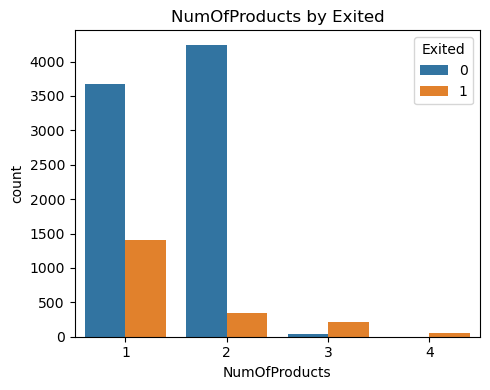

In [16]:
plt.figure(figsize=(5,4))
sns.countplot(data =df,x = 'NumOfProducts',hue='Exited')
plt.title('NumOfProducts by Exited')
plt.tight_layout()

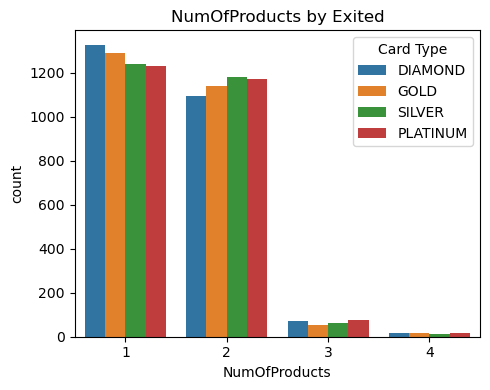

In [17]:
plt.figure(figsize=(5,4))
sns.countplot(data =df,x = 'NumOfProducts',hue='Card Type')
plt.title('NumOfProducts by Exited')
plt.tight_layout()

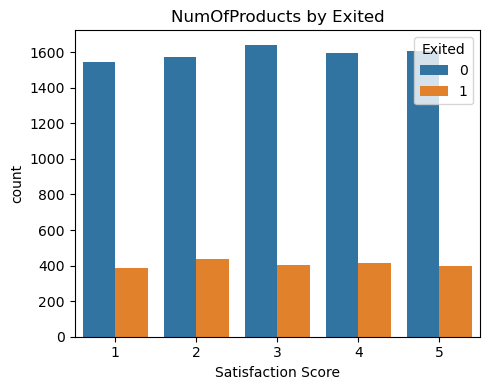

In [18]:
plt.figure(figsize=(5,4))
sns.countplot(data =df,x = 'Satisfaction Score',hue='Exited')
plt.title('NumOfProducts by Exited')
plt.tight_layout()

<Axes: xlabel='Satisfaction Score'>

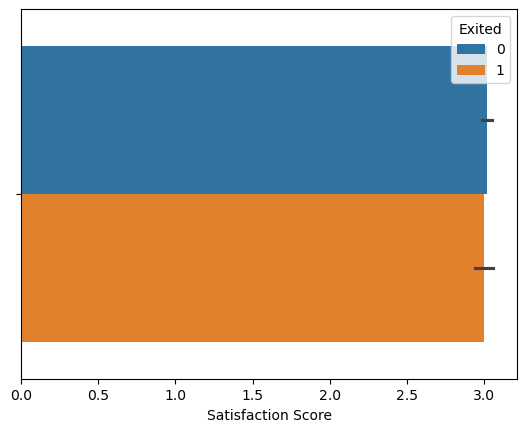

In [19]:
sns.barplot(data =df,x='Satisfaction Score',hue='Exited')

In [20]:
numeric_data=df.select_dtypes(include=np.number)
attributes = []
for col in numeric_data.columns:
    attributes.append(col)
attributes

['CreditScore',
 'Age',
 'Tenure',
 'Balance',
 'NumOfProducts',
 'HasCrCard',
 'IsActiveMember',
 'EstimatedSalary',
 'Exited',
 'Satisfaction Score',
 'Point Earned']

<Figure size 3000x3000 with 0 Axes>

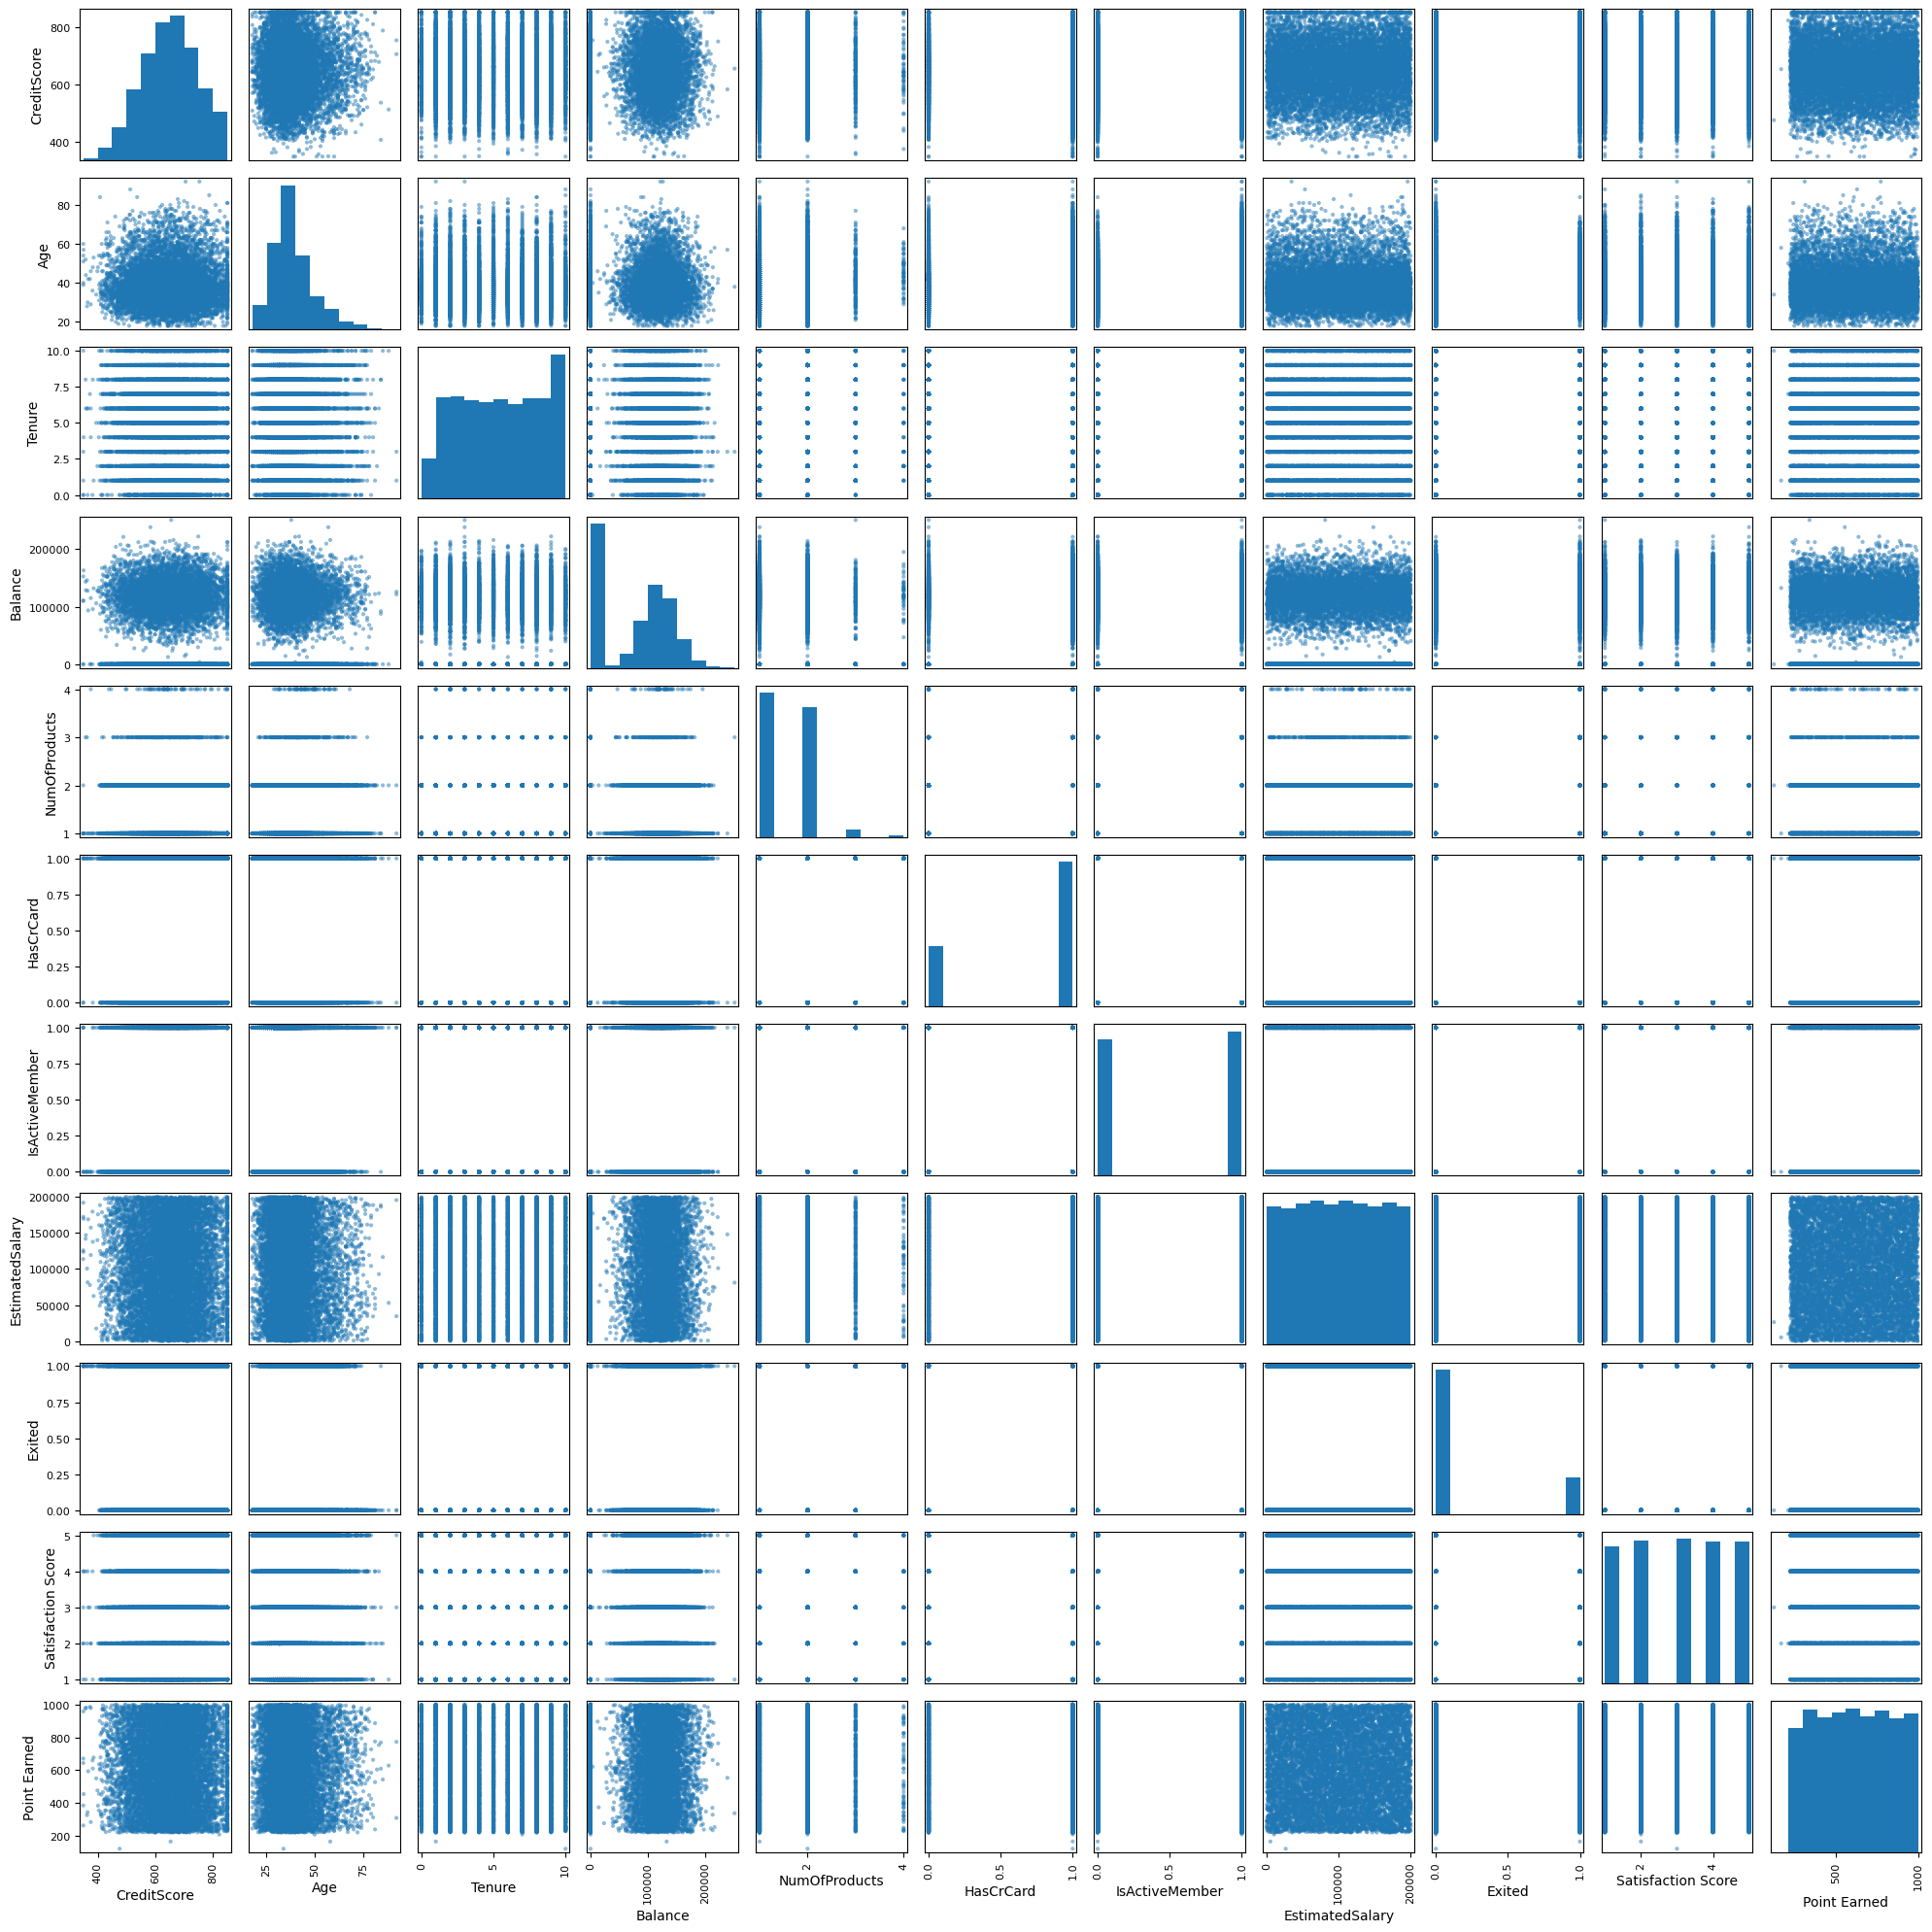

In [21]:
from pandas.plotting import scatter_matrix
plt.figure(figsize=(30,30))
scatter_matrix(df[attributes],figsize=(20,20))
plt.tight_layout()

<Axes: xlabel='Card Type', ylabel='count'>

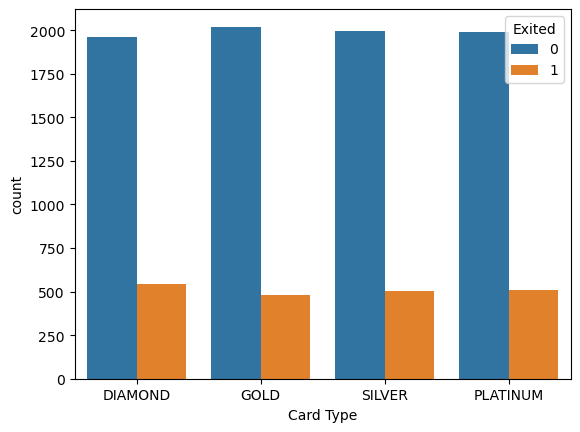

In [22]:
sns.countplot(data =df,x ='Card Type',hue ='Exited')

#### Handel Categorical Data


- For **Card** **Type** use maping for Diamond-3 , Gold-2 , Platinum-1 , Silver-0
- The Card Type was in this order - **Diamond** > **Gold** > **Platinum** > **Silver**
- For Gender & Geography use OneHot Encoding

In [23]:
maping = {'DIAMOND':3,
         'GOLD':2,
         'PLATINUM':1,
         'SILVER':0}
df['Card Type'] =  df['Card Type'].map(maping)

In [24]:
# import OneHotEncoder for handel categories
from sklearn.preprocessing import OneHotEncoder

In [25]:
ohe=OneHotEncoder()
encoder = ohe.fit_transform(df[['Gender']])

In [26]:
encoder.toarray()

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       ...,
       [1., 0.],
       [0., 1.],
       [1., 0.]])

In [27]:
encoded_df = pd.DataFrame(encoder.toarray(), columns=ohe.get_feature_names_out(),index= df[['Gender']].index)
encoded_df

,Gender_Female,Gender_Male
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
9995,0.0,1.0
9996,0.0,1.0
9997,1.0,0.0
9998,0.0,1.0


In [28]:
encoder_Geography= ohe.fit_transform(df[['Geography']])

In [29]:
encoder_Geography.toarray()

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [30]:
Geography_df= pd.DataFrame(encoder_Geography.toarray(),columns = ohe.get_feature_names_out(),index=df[['Geography']].index)
Geography_df.head()

,Geography_France,Geography_Germany,Geography_Spain
0,1.0,0.0,0.0
1,0.0,0.0,1.0
2,1.0,0.0,0.0
3,1.0,0.0,0.0
4,0.0,0.0,1.0


In [31]:
df = pd.concat([df,encoded_df,Geography_df],axis= 1)

In [32]:
df =df.drop(['Geography','Gender'],axis =1)

In [33]:
df.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
0,619,42,2,0.00,1,1,1,101348.88,1,2,3,464,1.0,0.0,1.0,0.0,0.0
1,608,41,1,83807.86,1,0,1,112542.58,0,3,3,456,1.0,0.0,0.0,0.0,1.0
2,502,42,8,159660.80,3,1,0,113931.57,1,3,3,377,1.0,0.0,1.0,0.0,0.0
3,699,39,1,0.00,2,0,0,93826.63,0,5,2,350,1.0,0.0,1.0,0.0,0.0
4,850,43,2,125510.82,1,1,1,79084.10,0,5,2,425,1.0,0.0,0.0,0.0,1.0


#### Scalling the Data

In [34]:
from sklearn.preprocessing import StandardScaler

num_col = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary','Satisfaction Score','Card Type','Point Earned']

scaler = StandardScaler()
df_scaled = df.copy()

df_scaled[num_col] = scaler.fit_transform(df_scaled[num_col])

In [35]:
df_scaled.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
0,-0.326221,0.293517,-1.041760,-1.225848,-0.911583,1,1,0.021886,1,-0.721130,1.339533,-0.630839,1.0,0.0,1.0,0.0,0.0
1,-0.440036,0.198164,-1.387538,0.117350,-0.911583,0,1,0.216534,0,-0.009816,1.339533,-0.666251,1.0,0.0,0.0,0.0,1.0
2,-1.536794,0.293517,1.032908,1.333053,2.527057,1,0,0.240687,1,-0.009816,1.339533,-1.015942,1.0,0.0,1.0,0.0,0.0
3,0.501521,0.007457,-1.387538,-1.225848,0.807737,0,0,-0.108918,0,1.412812,0.445319,-1.135457,1.0,0.0,1.0,0.0,0.0
4,2.063884,0.388871,-1.041760,0.785728,-0.911583,1,1,-0.365276,0,1.412812,0.445319,-0.803472,1.0,0.0,0.0,0.0,1.0


In [36]:
for col in df_scaled.columns:
    print('\n',col,':')
    print(f'Total unique Values : {len(df_scaled[col].unique())}')
    print('-'*50)
    print(df_scaled[col].value_counts().head(10))
    print('*'*50)


 CreditScore :
Total unique Values : 460
--------------------------------------------------
CreditScore
2.063884    233
0.284238     63
0.046263     54
0.563601     53
0.170424     53
0.346319     52
0.004875     50
0.201464     50
0.335972     48
0.015222     48
Name: count, dtype: int64
**************************************************

 Age :
Total unique Values : 70
--------------------------------------------------
Age
-0.183251    478
-0.087897    477
-0.373958    474
-0.278604    456
-0.469311    447
-0.564665    442
 0.102810    432
 0.007457    423
-0.660018    418
-0.755372    404
Name: count, dtype: int64
**************************************************

 Tenure :
Total unique Values : 11
--------------------------------------------------
Tenure
-1.041760    1048
-1.387538    1035
 0.687130    1028
 1.032908    1025
-0.004426    1012
-0.695982    1009
-0.350204     989
 1.378686     984
 0.341352     967
 1.724464     490
Name: count, dtype: int64
***********************

<Axes: ylabel='NumOfProducts'>

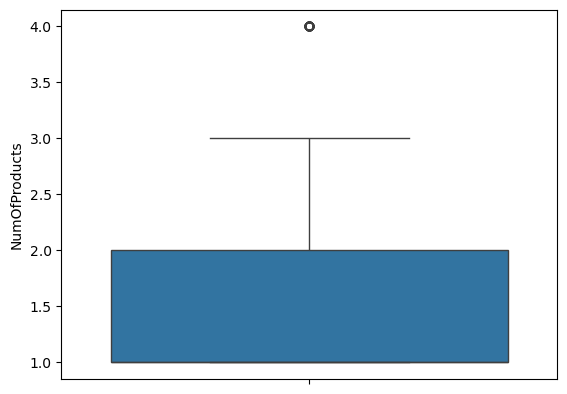

In [37]:
sns.boxplot(df['NumOfProducts'])

<Axes: xlabel='NumOfProducts', ylabel='count'>

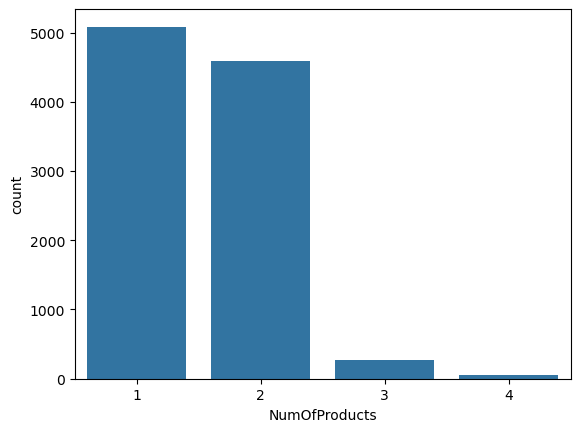

In [38]:
sns.countplot(data = df,x = 'NumOfProducts')

#### -> Separate the Feature and Target column
#### -> Split the data into 80:20 

In [39]:
df_copy = df.copy()
feature= df_copy.drop('Exited',axis =1)
target = df_copy['Exited']

In [40]:
from sklearn.model_selection import train_test_split


In [41]:
feature_train,feature_test,target_train,target_test = train_test_split(feature,target,random_state=42,test_size=0.2) # split in 80-20 ratio

In [42]:
print("feature_train")
print(feature_train)

print("\nfeature_test")
print(feature_test)

feature_train
      CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
9254          686   32       6       0.00              2          1   
1561          632   42       4  119624.60              2          1   
1670          559   24       3  114739.92              1          1   
6087          561   27       9  135637.00              1          1   
6669          517   56       9  142147.32              1          0   
...           ...  ...     ...        ...            ...        ...   
5734          768   54       8   69712.74              1          1   
5191          682   58       1       0.00              1          1   
5390          735   38       1       0.00              3          0   
860           667   43       8  190227.46              1          1   
7270          697   51       1  147910.30              1          1   

      IsActiveMember  EstimatedSalary  Satisfaction Score  Card Type  \
9254               1        179093.26                   2    

In [43]:
feature_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8000 entries, 9254 to 7270
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         8000 non-null   int64  
 1   Age                 8000 non-null   int64  
 2   Tenure              8000 non-null   int64  
 3   Balance             8000 non-null   float64
 4   NumOfProducts       8000 non-null   int64  
 5   HasCrCard           8000 non-null   int64  
 6   IsActiveMember      8000 non-null   int64  
 7   EstimatedSalary     8000 non-null   float64
 8   Satisfaction Score  8000 non-null   int64  
 9   Card Type           8000 non-null   int64  
 10  Point Earned        8000 non-null   int64  
 11  Gender_Female       8000 non-null   float64
 12  Gender_Male         8000 non-null   float64
 13  Geography_France    8000 non-null   float64
 14  Geography_Germany   8000 non-null   float64
 15  Geography_Spain     8000 non-null   float64
dtypes: float

#### Binary data was already in the form of 0-1 
#### Now Scale the Continuous data 
#### We are not scalle the target_train data because it has already in the form of 0-1

In [44]:
from sklearn.preprocessing import StandardScaler

s_d = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary','Satisfaction Score','Card Type','Point Earned']

scaler = StandardScaler()
feature_train[s_d] = scaler.fit_transform(feature_train[s_d])
feature_test[s_d] = scaler.transform(feature_test[s_d])

In [45]:
feature_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned,Gender_Female,Gender_Male,Geography_France,Geography_Germany,Geography_Spain
9254,0.356500,-0.655786,0.345680,-1.218471,0.808436,1,1,1.367670,-0.720010,1.340729,-0.430193,0.0,1.0,1.0,0.0,0.0
1561,-0.203898,0.294938,-0.348369,0.696838,0.808436,1,1,1.661254,0.704342,-0.450642,1.565908,0.0,1.0,0.0,1.0,0.0
1670,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,1,0,-0.252807,0.704342,-1.346327,-1.243749,0.0,1.0,0.0,0.0,1.0
6087,-0.940717,-1.131148,1.386753,0.953212,-0.916688,1,0,0.915393,-0.720010,-1.346327,-0.176791,1.0,0.0,1.0,0.0,0.0
6669,-1.397337,1.625953,1.386753,1.057449,-0.916688,0,0,-1.059600,-0.007834,-0.450642,0.534515,0.0,1.0,1.0,0.0,0.0


#### Train the model using
- **Logistic** **Regression**
- **Random** **Forest** **Classifier**

##### And also check the classification_report, accuracy_score

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

print("--- LOGISTIC REGRESSION RESULTS ---")
lr_model = LogisticRegression(random_state=42)
lr_model.fit(feature_train, target_train)

lr_preds = lr_model.predict(feature_test)
lr_probs = lr_model.predict_proba(feature_test)[:, 1]

print(f"Accuracy: {accuracy_score(target_test, lr_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(target_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(target_test, lr_preds))


print("--- DECESSION TREE CLASSIFIER RESULTS ---")
dts_model = DecisionTreeClassifier(random_state=42)
dts_model.fit(feature_train, target_train)

dts_preds = dts_model.predict(feature_test)
dts_probs = dts_model.predict_proba(feature_test)[:, 1]

print(f"Accuracy: {accuracy_score(target_test, dts_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(target_test, dts_probs):.4f}")
print("\nClassification Report:")
print(classification_report(target_test, dts_preds))


print("--- RANDOM FOREST RESULTS ---")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(feature_train, target_train)

rf_preds = rf_model.predict(feature_test)
rf_probs = rf_model.predict_proba(feature_test)[:, 1]

print(f"Accuracy: {accuracy_score(target_test, rf_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(target_test, rf_probs):.4f}")
print("\nClassification Report:")
print(classification_report(target_test, rf_preds))

--- LOGISTIC REGRESSION RESULTS ---
Accuracy: 0.8115
ROC-AUC Score: 0.7789

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.56      0.20      0.30       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000

--- DECESSION TREE CLASSIFIER RESULTS ---
Accuracy: 0.7850
ROC-AUC Score: 0.6769

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.86      0.86      1607
           1       0.46      0.50      0.48       393

    accuracy                           0.79      2000
   macro avg       0.67      0.68      0.67      2000
weighted avg       0.79      0.79      0.79      2000

--- RANDOM FOREST RESULTS ---
Accuracy: 0.8630
ROC-AUC Score: 0.8580

Classification Report:
              precision    recall  f1-score   sup

According to this model comparision Random Forest Classifier gives better accuracy

In [47]:
feature_imp = pd.Series(
    rf_model.feature_importances_,
    index=feature.columns
).sort_values(ascending=False)

print(feature_imp)

Age                   0.211632
NumOfProducts         0.123169
Balance               0.107415
EstimatedSalary       0.104827
CreditScore           0.101835
Point Earned          0.100726
Tenure                0.061394
Satisfaction Score    0.040365
IsActiveMember        0.040030
Card Type             0.034946
Geography_Germany     0.019913
HasCrCard             0.015260
Gender_Female         0.010433
Geography_France      0.009873
Geography_Spain       0.009197
Gender_Male           0.008985
dtype: float64


df_copy

In [48]:
df_copy = df_copy.drop(['HasCrCard','Gender_Female','Gender_Male','Geography_France','Geography_Spain','Geography_Germany'],axis =1)

In [49]:
df_copy.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Exited,Satisfaction Score,Card Type,Point Earned
0,619,42,2,0.00,1,1,101348.88,1,2,3,464
1,608,41,1,83807.86,1,1,112542.58,0,3,3,456
2,502,42,8,159660.80,3,0,113931.57,1,3,3,377
3,699,39,1,0.00,2,0,93826.63,0,5,2,350
4,850,43,2,125510.82,1,1,79084.10,0,5,2,425


In [52]:
feature= df_copy.drop('Exited',axis =1)
target = df_copy['Exited']

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

feature_train,feature_test,target_train,target_test = train_test_split(feature,target,random_state=42,test_size=0.2) # split in 80-20 ratio


s_d = ['CreditScore','Age','Tenure','Balance','NumOfProducts','EstimatedSalary','Satisfaction Score','Card Type','Point Earned']

scaler = StandardScaler()
feature_train[s_d] = scaler.fit_transform(feature_train[s_d])
feature_test[s_d] = scaler.transform(feature_test[s_d])
feature_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,IsActiveMember,EstimatedSalary,Satisfaction Score,Card Type,Point Earned
9254,0.356500,-0.655786,0.345680,-1.218471,0.808436,1,1.367670,-0.720010,1.340729,-0.430193
1561,-0.203898,0.294938,-0.348369,0.696838,0.808436,1,1.661254,0.704342,-0.450642,1.565908
1670,-0.961472,-1.416365,-0.695393,0.618629,-0.916688,0,-0.252807,0.704342,-1.346327,-1.243749
6087,-0.940717,-1.131148,1.386753,0.953212,-0.916688,0,0.915393,-0.720010,-1.346327,-0.176791
6669,-1.397337,1.625953,1.386753,1.057449,-0.916688,0,-1.059600,-0.007834,-0.450642,0.534515


In [53]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score


print("--- LOGISTIC REGRESSION RESULTS ---")
lr_model = LogisticRegression(random_state=42)
lr_model.fit(feature_train, target_train)

lr_preds = lr_model.predict(feature_test)
lr_probs = lr_model.predict_proba(feature_test)[:, 1]

print(f"Accuracy: {accuracy_score(target_test, lr_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(target_test, lr_probs):.4f}")
print("\nClassification Report:")
print(classification_report(target_test, lr_preds))


print("--- DECESSION TREE CLASSIFIER RESULTS ---")
dts_model = DecisionTreeClassifier(random_state=42,
                                   min_samples_leaf=10,
                                   max_depth=5)
dts_model.fit(feature_train, target_train)

dts_preds = dts_model.predict(feature_test)
dts_probs = dts_model.predict_proba(feature_test)[:, 1]

print(f"Accuracy: {accuracy_score(target_test, dts_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(target_test, dts_probs):.4f}")
print("\nClassification Report:")
print(classification_report(target_test, dts_preds))


print("--- RANDOM FOREST RESULTS ---")
rf_model = RandomForestClassifier(random_state=42,class_weight='balanced')
rf_model.fit(feature_train, target_train)

rf_preds = rf_model.predict(feature_test)
rf_probs = rf_model.predict_proba(feature_test)[:, 1]

print(f"Accuracy: {accuracy_score(target_test, rf_preds):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(target_test, rf_probs):.4f}")
print("\nClassification Report:")
print(classification_report(target_test, rf_preds))

--- LOGISTIC REGRESSION RESULTS ---
Accuracy: 0.8095
ROC-AUC Score: 0.7564

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1607
           1       0.56      0.15      0.24       393

    accuracy                           0.81      2000
   macro avg       0.69      0.56      0.56      2000
weighted avg       0.77      0.81      0.76      2000

--- DECESSION TREE CLASSIFIER RESULTS ---
Accuracy: 0.8580
ROC-AUC Score: 0.8321

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.97      0.92      1607
           1       0.77      0.40      0.52       393

    accuracy                           0.86      2000
   macro avg       0.82      0.68      0.72      2000
weighted avg       0.85      0.86      0.84      2000

--- RANDOM FOREST RESULTS ---
Accuracy: 0.8605
ROC-AUC Score: 0.8347

Classification Report:
              precision    recall  f1-score   sup

So now we can't remove **('HasCrCard','Gender_Female','Gender_Male','Geography_France','Geography_Spain','Geography_Germany')** these columns ,
because if remove the columns it reduce the accuracy of our model